# Определение стоимости автомобилей

Задача:
Разработать модель для точного и быстрого определения рыночной стоимости автомобилей с пробегом на основе исторических данных.

Цель:
Создать эффективный инструмент, который позволит пользователям сервиса «Не бит, не крашен» быстро и с высокой точностью оценивать стоимость своего автомобиля.

Вводные данные:
В распоряжении имеются исторические данные по автомобилям с пробегом, включающие технические характеристики, комплектации и цены. Необходимо использовать эти данные для построения модели, которая будет предсказывать цену автомобиля.

Требования заказчика:

Высокое качество предсказания (точность и адекватность оценок);
Быстрое получение предсказаний в приложении;
Минимальное время обучения модели для оперативного обновления.

Задача и цель

Необходимо построить модель для определения рыночной стоимости автомобилей с пробегом на основе данных о технических характеристиках, комплектации и ценах аналогичных автомобилей. Цель проекта — создать точный и эффективный инструмент, который будет использоваться в мобильном приложении сервиса «Не бит, не крашен» для привлечения новых клиентов и предоставления им возможности быстро и достоверно оценить стоимость своего автомобиля.

Вводная информация

Сервис «Не бит, не крашен» специализируется на продаже автомобилей с пробегом и разрабатывает приложение с функцией оценки стоимости автомобиля. В распоряжении имеется набор данных, включающий технические характеристики автомобилей, комплектации и их рыночные цены. Для решения задачи необходимо построить модель, которая будет предсказывать стоимость автомобиля с учётом этих параметров.

Ключевые критерии, важные для заказчика:

Качество предсказания (точность оценки стоимости);

Время обучения модели (эффективность подготовки модели);

Время предсказания модели (скорость выдачи результата пользователю).

Рекомендуется не ограничиваться только методами градиентного бустинга, а также протестировать более простые модели, поскольку они могут показать лучшие результаты по времени обучения и предсказания без существенной потери качества. Важно провести сравнение различных моделей по указанным критериям для выбора оптимального решения.


Надо сравнить несколько моделей машинного обучения для предсказания целевой переменной на основе данных из файла /datasets/autos.csv. Основная цель — подобрать модель с метрикой RMSE ниже 2500, оптимизировать её по времени обучения и предсказания, а также проверить качество на тестовой выборке.

Что у меня есть:

Данные содержатся в CSV-файле по пути /datasets/autos.csv.
В данных могут присутствовать пропущенные значения и аномалии, которые необходимо корректно обработать.
Среди признаков могут быть неинформативные, которые нужно удалить.
Для обучения моделей требуется подготовить обучающую и тестовую выборки.
Необходимо обучить несколько моделей, включая LightGBM и как минимум одну модель, не основанную на бустинге (например, линейную регрессию, случайный лес и т.п.).
Для каждой модели нужно провести настройку гиперпараметров (не более 2-3 параметров для LightGBM).
Оценка качества моделей проводится по метрике RMSE, которая должна быть меньше 2500.
При работе с Jupyter Notebook следует контролировать время выполнения ячеек и при необходимости освобождать память, удаляя лишние переменные.
Важно самостоятельно освоить библиотеку LightGBM и использовать её для построения моделей градиентного бустинга.


Мне нужно:

Загрузить данные из /datasets/autos.csv.
Исследовать данные, заполнить пропуски, обработать аномалии, удалить неинформативные признаки.
Подготовить обучающую и тестовую выборки.
Обучить несколько моделей, включая LightGBM и как минимум одну модель без бустинга, с настройкой гиперпараметров.
Проанализировать время обучения, время предсказания и качество моделей по RMSE.
Выбрать лучшую модель по критериям заказчика и проверить её качество на тестовой выборке.

Описание данных

Данные находятся в файле /datasets/autos.csv.

Признаки

DateCrawled — дата скачивания анкеты из базы

VehicleType — тип автомобильного кузова

RegistrationYear — год регистрации автомобиля

Gearbox — тип коробки передач

Power — мощность (л. с.)

Model — модель автомобиля

Kilometer — пробег (км)

RegistrationMonth — месяц регистрации автомобиля

FuelType — тип топлива

Brand — марка автомобиля

Repaired — была машина в ремонте или нет

DateCreated — дата создания анкеты

NumberOfPictures — количество фотографий автомобиля

PostalCode — почтовый индекс владельца анкеты (пользователя)

LastSeen — дата последней активности пользователя


Целевой признак

Price — цена (евро)

In [1]:
!pip install -U -q scikit-learn
!pip install -q phik
#!pip install numpy
#!pip install --upgrade matplotlib


In [2]:
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV
)


from sklearn.metrics import (
    mean_squared_error,
    make_scorer
)


from phik import phik_matrix
import phik
from phik.report import plot_correlation_matrix

from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", seaborn.__version__)
   


## Подготовка данных

Загрузите данные, путь к файлу: /datasets/autos.csv.


In [3]:
autos_data = pd.read_csv('/datasets/autos.csv')


Изучите данные. Заполните пропущенные значения и обработайте аномалии в столбцах. Если среди признаков имеются неинформативные, удалите их.


In [4]:
autos_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

Пропуски в  VehicleType (тип кузова) Gearbox (тип коробки передач)  Model (модель автомобиля)  FuelType (тип топлива) Repaired (была машина в ремонте или нет)

DateCrawled (дата скачивания анкеты из базы) DateCreated (дата создания анкеты) и LastSeen (дата последней активности пользователя) не в том формате

In [5]:
autos_data.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [6]:
autos_data.describe()

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


Почему минимальные мощность и цена машины равны нулю? 20000 лошадиных сил?
А минимальный год регистрации - 1000? Карета что-ли?
А максимальный год 9999.
Выбросов много.

In [7]:
autos_data.duplicated().sum()

4

In [8]:
autos_data = autos_data.drop_duplicates()
print(autos_data.duplicated().sum())

0


От каких признаков зависит целевой? То есть, какие параметры влияют на цену автомобиля?
Прежде чем заполнять пропуски, надо понять важность признаков, в которых отсутствуют значения. И все пять признаков по логике влияют на цену. Значит будем обрабатывать.

Признаки, которые можно удалить:

NumberOfPictures (количество фото авто),
PostalCode — (почтовый индекс владельца анкеты (пользователя)),  
DateCrawled - (дата скачивания анкеты из базы),
LastSeen — дата последней активности пользователя

Они помешают модели и на их основе нельзя получить новые полезные признаки

In [9]:
autos_data_mod = autos_data[['VehicleType',
                             'Gearbox',
                             'Power',
                             'Kilometer',
                             'FuelType',
                             'Brand', 
                             'Repaired',
                             'RegistrationYear',
                             'RegistrationMonth',
                             'Model',
                             'Price']]

#, 'DateCreated'
autos_data_mod.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 354365 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   VehicleType        316875 non-null  object
 1   Gearbox            334532 non-null  object
 2   Power              354365 non-null  int64 
 3   Kilometer          354365 non-null  int64 
 4   FuelType           321470 non-null  object
 5   Brand              354365 non-null  object
 6   Repaired           283211 non-null  object
 7   RegistrationYear   354365 non-null  int64 
 8   RegistrationMonth  354365 non-null  int64 
 9   Model              334660 non-null  object
 10  Price              354365 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 32.4+ MB


In [10]:
sorted(autos_data_mod['RegistrationMonth'].unique())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [11]:
autos_data_mod['RegistrationMonth'].isna().sum()


0

In [12]:
autos_data_mod['RegistrationMonth'].value_counts()

0     37352
3     34373
6     31507
4     29270
5     29153
7     27211
10    26099
12    24289
11    24186
9     23813
1     23218
8     22627
2     21267
Name: RegistrationMonth, dtype: int64

Эти 4 признака заменю на моду





In [13]:
autos_data_mod['Model'].fillna(autos_data_mod['Model'].mode()[0], inplace=True)


/opt/conda/lib/python3.9/site-packages/pandas/core/series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


Чем можно заполнить пропуски в VehicleType (тип кузова), Gearbox (тип коробки передач) и FuelType (тип топлива)?
Это все комплектующие авто. А все авто сделаны по стандарту, если оглядываться на логику. Кастомные автомобили компании обычно не производят. Все они сделаны по стандартному шаблону. А Это, в свою очередь означает, что эти 3 типа признаков связаны с самой моделью или брендом автомобиля.

In [14]:
autos_data_mod['VehicleType'] = (autos_data_mod.groupby(['Brand', 'Model'])['VehicleType'].transform(lambda x: x.fillna(value=(x.mode()[0] if not x.mode().empty else "unknown"))))
autos_data_mod['FuelType'] = (autos_data_mod.groupby(['Brand', 'Model'])['FuelType'].transform(lambda x: x.fillna(value=(x.mode()[0] if not x.mode().empty else "unknown"))))
autos_data_mod['Gearbox'] = (autos_data_mod.groupby(['Brand', 'Model'])['Gearbox'].transform(lambda x: x.fillna(value=(x.mode()[0] if not x.mode().empty else "unknown"))))

/tmp/ipykernel_117/2527937397.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  autos_data_mod['VehicleType'] = (autos_data_mod.groupby(['Brand', 'Model'])['VehicleType'].transform(lambda x: x.fillna(value=(x.mode()[0] if not x.mode().empty else "unknown"))))
/tmp/ipykernel_117/2527937397.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  autos_data_mod['FuelType'] = (autos_data_mod.groupby(['Brand', 'Model'])['FuelType'].transform(lambda x: x.fillna(value=(x.mode()[0] if not x.mode().empty else "unknown

А в этом признаке слишком много пропущенных значений. Удалять не буду. 


Была ли машина в ремонте? Если не написано - значит не была. Или заменить пустые значения на 'Unknown'??

In [15]:
#autos_data_mod['Repaired'] = autos_data_mod['Repaired'].fillna('no')

autos_data_mod['Repaired'] = autos_data_mod['Repaired'].fillna('unknown')


/tmp/ipykernel_117/976901408.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  autos_data_mod['Repaired'] = autos_data_mod['Repaired'].fillna('unknown')


А тут просто изменю тип данных

In [16]:
#autos_data_mod['DateCreated'] = pd.to_datetime(autos_data_mod['DateCreated'], errors='coerce')

In [17]:
autos_data_mod.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 354365 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   VehicleType        354365 non-null  object
 1   Gearbox            354365 non-null  object
 2   Power              354365 non-null  int64 
 3   Kilometer          354365 non-null  int64 
 4   FuelType           354365 non-null  object
 5   Brand              354365 non-null  object
 6   Repaired           354365 non-null  object
 7   RegistrationYear   354365 non-null  int64 
 8   RegistrationMonth  354365 non-null  int64 
 9   Model              354365 non-null  object
 10  Price              354365 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 32.4+ MB


In [18]:
autos_data_mod.head()

,VehicleType,Gearbox,Power,Kilometer,FuelType,Brand,Repaired,RegistrationYear,RegistrationMonth,Model,Price
0,sedan,manual,0,150000,petrol,volkswagen,unknown,1993,0,golf,480
1,coupe,manual,190,125000,gasoline,audi,yes,2011,5,golf,18300
2,suv,auto,163,125000,gasoline,jeep,unknown,2004,8,grand,9800
3,small,manual,75,150000,petrol,volkswagen,no,2001,6,golf,1500
4,small,manual,69,90000,gasoline,skoda,no,2008,7,fabia,3600


In [19]:
display(autos_data_mod.describe())



,Power,Kilometer,RegistrationYear,RegistrationMonth,Price
count,354365.000000,354365.000000,354365.000000,354365.000000,354365.000000
mean,110.093816,128211.363989,2004.234481,5.714650,4416.679830
std,189.851330,37905.083858,90.228466,3.726432,4514.176349
min,0.000000,5000.000000,1000.000000,0.000000,0.000000
25%,69.000000,125000.000000,1999.000000,3.000000,1050.000000
50%,105.000000,150000.000000,2003.000000,6.000000,2700.000000
75%,143.000000,150000.000000,2008.000000,9.000000,6400.000000
max,20000.000000,150000.000000,9999.000000,12.000000,20000.000000


In [20]:
autos_data_mod = autos_data_mod[autos_data_mod['Price'] != 0]


In [21]:
#autos_data_mod = autos_data_mod[autos_data_mod['Power'] != 0]

Как я узнал ниже, Power хорошо коррелирует с VehicleType, Gearbox, Brand, Price и особенно с Model. Использую последний.

In [22]:

autos_data_mod['Power'] = autos_data_mod['Power'].replace(0, np.nan)

# Заполняем пропуски медианой мощности по модели
autos_data_mod['Power'] = autos_data_mod.groupby('Model')['Power'].transform(lambda x: x.fillna(x.median()))


/opt/conda/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1117: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [23]:
sorted(autos_data_mod['RegistrationYear'].unique())

[1000,
 1001,
 1039,
 1111,
 1234,
 1255,
 1300,
 1400,
 1500,
 1600,
 1602,
 1800,
 1910,
 1923,
 1925,
 1927,
 1928,
 1929,
 1930,
 1931,
 1932,
 1933,
 1934,
 1935,
 1936,
 1937,
 1938,
 1940,
 1941,
 1942,
 1943,
 1944,
 1945,
 1946,
 1947,
 1948,
 1949,
 1950,
 1951,
 1952,
 1953,
 1954,
 1955,
 1956,
 1957,
 1958,
 1959,
 1960,
 1961,
 1962,
 1963,
 1964,
 1965,
 1966,
 1967,
 1968,
 1969,
 1970,
 1971,
 1972,
 1973,
 1974,
 1975,
 1976,
 1977,
 1978,
 1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2066,
 2200,
 2222,
 2290,
 2500,
 2800,
 2900,
 3000,
 3200,
 3700,
 3800,
 4000,
 4100,
 4500,
 4800,
 5000,
 5300,
 5555,
 5600,
 5900,
 5911,
 6000,
 6500,
 7000,
 7100,
 7800,
 8000,
 8200,
 8500,
 8888,
 9000,
 9450,
 9999]

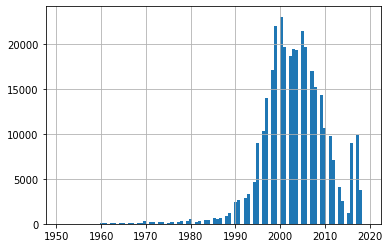

In [24]:
autos_data_mod[(autos_data_mod['RegistrationYear']>1950) & (autos_data_mod['RegistrationYear']<2022)]['RegistrationYear'].hist(bins = 100);

In [25]:
autos_data_mod = autos_data_mod.query('1960 < RegistrationYear < 2016')
autos_data_mod['RegistrationYear'].describe()

count    320370.000000
mean       2002.290745
std           6.318676
min        1961.000000
25%        1999.000000
50%        2003.000000
75%        2007.000000
max        2015.000000
Name: RegistrationYear, dtype: float64

In [26]:
current_year = 2016
current_month = 3 #апрель, если считать с 0
autos_data_mod['AgeInMonths'] = (current_year - autos_data_mod['RegistrationYear']) * 12 + (current_month - autos_data_mod['RegistrationMonth'])


In [27]:
autos_data_mod['AgeInMonths'].describe()

count    320370.000000
mean        161.656756
std          76.230394
min           3.000000
25%         109.000000
50%         158.000000
75%         204.000000
max         663.000000
Name: AgeInMonths, dtype: float64

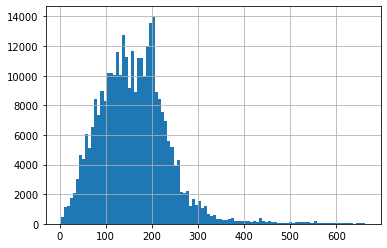

In [28]:
autos_data_mod['AgeInMonths'].hist(bins = 100);

<AxesSubplot:title={'center':'Цена'}>

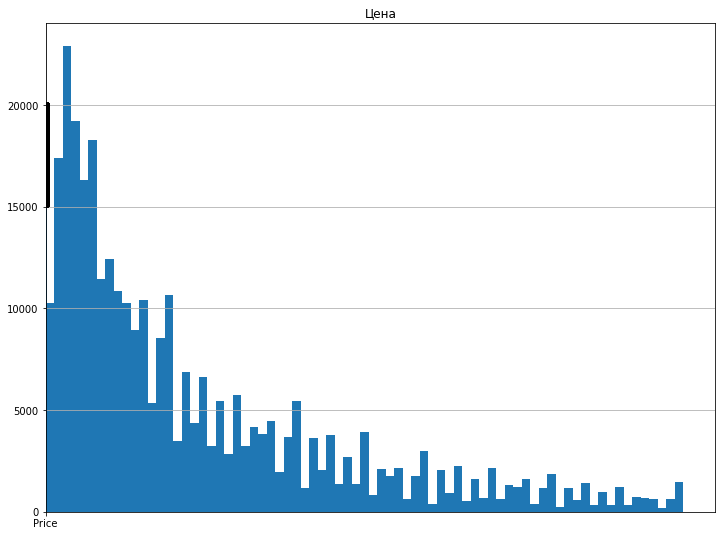

In [29]:
autos_data_mod['Price'].hist(bins=75, figsize=(12,9))
autos_data_mod['Price'].plot(kind='box', title='Цена', grid= True)

Обработаем ключевой признак

In [30]:
autos_data_mod = autos_data_mod.query('50 < Power < 400')
autos_data_mod['Power'].describe()

count    309806.000000
mean        121.783090
std          50.530161
min          51.000000
25%          83.000000
50%         115.000000
75%         150.000000
max         399.000000
Name: Power, dtype: float64

corr = autos_data_mod.corr()
sns.heatmap(corr)

VehicleType ['bus' 'convertible' 'coupe' 'other' 'sedan' 'small' 'suv' 'wagon']

Gearbox ['auto' 'manual']

Power [ 51.   52.   53.   54.   55.   56.   57.   58.   59.   60.   61.   62.
  63.   64.   65.   66.   67.   68.   69.   69.5  70.   71.   72.   73.
  74.   75.   76.   77.   78.   79.   80.   81.   82.   83.   83.5  84.
  85.   86.   87.   88.   89.   90.   91.   92.   93.   94.   95.   96.
  97.   98.   99.  100.  101.  102.  103.  104.  105.  106.  107.  108.
 109.  109.5 110.  111.  112.  113.  114.  115.  116.  117.  118.  119.
 120.  121.  122.  123.  124.  125.  126.  127.  128.  129.  130.  131.
 132.  133.  134.  135.  136.  137.  138.  139.  140.  141.  142.  143.
 144.  145.  146.  146.5 147.  148.  149.  150.  151.  152.  153.  154.
 155.  156.  157.  158.  159.  160.  161.  162.  163.  164.  165.  166.
 167.  168.  169.  170.  171.  172.  173.  174.  175.  176.  177.  178.
 179.  180.  181.  182.  183.  184.  185.  186.  187.  188.  189.  190.
 191.  192.  193.  194

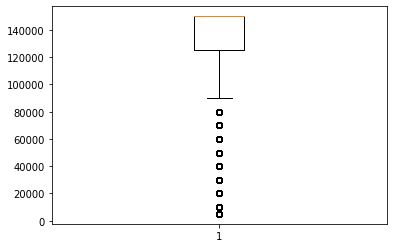

FuelType ['cng' 'electric' 'gasoline' 'hybrid' 'lpg' 'other' 'petrol']

Brand ['alfa_romeo' 'audi' 'bmw' 'chevrolet' 'chrysler' 'citroen' 'dacia'
 'daewoo' 'daihatsu' 'fiat' 'ford' 'honda' 'hyundai' 'jaguar' 'jeep' 'kia'
 'lada' 'lancia' 'land_rover' 'mazda' 'mercedes_benz' 'mini' 'mitsubishi'
 'nissan' 'opel' 'peugeot' 'porsche' 'renault' 'rover' 'saab' 'seat'
 'skoda' 'smart' 'sonstige_autos' 'subaru' 'suzuki' 'toyota' 'trabant'
 'volkswagen' 'volvo']

Repaired ['no' 'unknown' 'yes']

RegistrationYear [1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974
 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988
 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002
 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015]



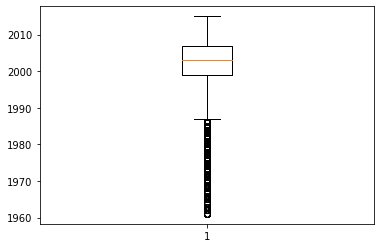

RegistrationMonth [ 0  1  2  3  4  5  6  7  8  9 10 11 12]



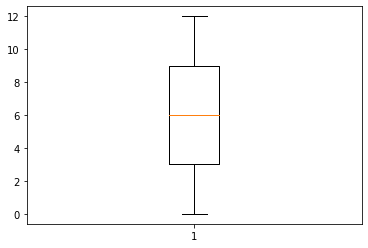

Model ['100' '145' '147' '156' '159' '1_reihe' '1er' '200' '2_reihe' '300c'
 '3_reihe' '3er' '4_reihe' '500' '5_reihe' '5er' '6_reihe' '6er' '7er'
 '80' '850' '90' '900' '9000' '911' 'a1' 'a2' 'a3' 'a4' 'a5' 'a6' 'a8'
 'a_klasse' 'accord' 'agila' 'alhambra' 'almera' 'altea' 'amarok' 'antara'
 'arosa' 'astra' 'auris' 'avensis' 'aveo' 'aygo' 'b_klasse' 'b_max'
 'beetle' 'berlingo' 'bora' 'boxster' 'bravo' 'c1' 'c2' 'c3' 'c4' 'c5'
 'c_klasse' 'c_max' 'c_reihe' 'caddy' 'calibra' 'captiva' 'carisma'
 'carnival' 'cayenne' 'cc' 'ceed' 'charade' 'cherokee' 'citigo' 'civic'
 'cl' 'clio' 'clk' 'clubman' 'colt' 'combo' 'cooper' 'cordoba' 'corolla'
 'corsa' 'cr_reihe' 'croma' 'crossfire' 'cuore' 'cx_reihe' 'defender'
 'delta' 'discovery' 'doblo' 'ducato' 'duster' 'e_klasse' 'elefantino'
 'eos' 'escort' 'espace' 'exeo' 'fabia' 'fiesta' 'focus' 'forester'
 'forfour' 'fortwo' 'fox' 'freelander' 'fusion' 'g_klasse' 'galant'
 'galaxy' 'getz' 'gl' 'glk' 'golf' 'grand' 'i3' 'i_reihe' 'ibiza'
 'impreza' '

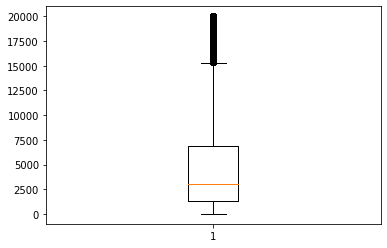

AgeInMonths [  3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20
  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38
  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56
  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74
  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92
  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110
 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128
 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146
 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164
 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182
 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218
 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236
 237 238 239 240 241 242 243 244 245 24

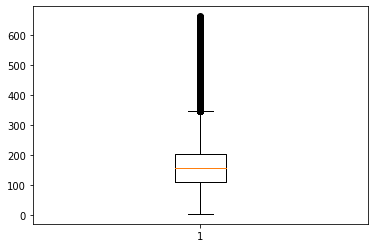

In [31]:
def fun(col):
    for i in col:
        print(i, autos_data_mod[i].sort_values().unique())
        print()
        if autos_data_mod[i].dtypes == 'int64':
            plt.boxplot(autos_data_mod[i])
            plt.show()
    
fun(autos_data_mod.columns)

In [32]:


interval_cols = ['Power', 'Kilometer', 'RegistrationYear', 'RegistrationMonth', 'Price', 'AgeInMonths']  
phik_corr = autos_data_mod.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(12, 10))
sns.heatmap(phik_corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            square=True,
            cbar_kws={"shrink": .8})
plt.title("Phik Correlation Matrix")
plt.show()


KeyboardInterrupt: 

С Price кореллируют по убыванию:
AgeInMonths - 0.69
RegistrationYear- 0.68

Разумеется, возраст автомобиля и год регистрации сильно влияют на цену.

Чем старше автомобиль (больше AgeInMonths) и чем раньше год регистрации, тем ниже цена. Логика вроде есть, так как автомобили теряют стоимость с возрастом. Банально становятся не модными и не надежными.

Model - 0.57
Power - 0.50

Разные модели и мощность двигателя существенно влияют на цену, что отражает рыночные предпочтения и характеристики автомобиля.



Brand - 0.36
Repaired - 0.36
Бренд, состояние ремонта, коробка передач и пробег влияют умеренно



Эти маловыражены
Gearbox - 0.32
Kilometer - 0.32
FuelType - 0.26
VehicleType - 0.26

Месяц рассматривать не стоит
RegistrationMonth - 0.16


Все поддается логике и ожиданиям, так как с возрастом автомобиль теряет стоимость, а характеристики модели и мощности отражают его рыночную ценность. Цена - вот наш ключевой признак. На основании вышеизложенной информации мы будем двигаться дальше.

In [ ]:
cat_features = ['VehicleType', 'Gearbox', 'Model', 'RegistrationMonth', 'FuelType', 'Brand', 'Repaired']
num_features = ['RegistrationYear', 'Power', 'Kilometer', 'AgeInMonths']

X = autos_data_mod[num_features + cat_features]
y = autos_data_mod['Price']


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
#индексы не будут сбрасывться
#X_train = X_train.reset_index(drop=True)
#X_val = X_val.reset_index(drop=True)
#X_test = X_test.reset_index(drop=True)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features), 
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

In [ ]:

X_train = pipeline.fit_transform(X_train)
X_val = pipeline.transform(X_val)
X_test = pipeline.transform(X_test)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


А теперь можно переходить к делу.

## Обучение моделей

Подготовьте выборки для обучения моделей.


In [ ]:
RMSE_score = 'neg_root_mean_squared_error'

Обучите разные модели, одна из которых — LightGBM, как минимум одна — не бустинг. Для каждой модели попробуйте разные гиперпараметры.


### LGBMRegressor

In [ ]:
# Подбор гиперпараметров (пример для LGBM)
lg = LGBMRegressor(random_state=42)
lg_params = {
    "max_depth": [10, 40, 50],
    "learning_rate": [0.1, 0.2],
    "num_leaves": [60, 300],
    "n_estimators": [5, 10]
}


In [ ]:
grid_lg = GridSearchCV(lg, lg_params, scoring=RMSE_score, cv=3, n_jobs=-1, verbose=1)
start = time.time()
grid_lg.fit(X_train, y_train)
end = time.time()

print("Лучшие параметры LGBM:", grid_lg.best_params_)
print("Лучший RMSE CV:", -grid_lg.best_score_)

print("время обучения на трейне:", grid_lg.refit_time_)

print(f"Время подбора параметров (GridSearchCV): {end - start:.2f} сек")




In [ ]:
# Обучение финальной модели на всей train_val с лучшими параметрами
best_lg = LGBMRegressor(**grid_lg.best_params_, random_state=42)
best_lg.fit(X_val, y_val)

In [ ]:
start_pred_time = time.time()
predictions = best_lg.predict(X_val)
print(f"Время предсказания: {time.time() - start_pred_time:.4f} сек")

### LinearRegression

In [ ]:
# Инициализация модели
lr = LinearRegression()

# Оценка модели с использованием кросс-валидации
start_cv_time = time.time()
cv_scores = cross_val_score(lr, X_train, y_train, scoring=RMSE_score, cv=3)
end_cv_time = time.time()

print(f"Лучший RMSE CV: {-np.mean(cv_scores):.2f}")
print(f"Время на тренировочных данных: {end_cv_time - start_cv_time:.2f} сек")


In [ ]:
# Обучение финальной модели на всей train_val выборке
start_cv_time = time.time()
lr.fit(X_val, y_val)
end_cv_time = time.time()
print(f"Время fit на валидационных данных: {end_cv_time - start_cv_time:.2f} сек")

In [ ]:
start_pred_time = time.time()
predictions = lr.predict(X_val)
print(f"Время предсказания: {time.time() - start_pred_time:.4f} сек")

### RandomForestRegressor

In [ ]:
# Создаем модель RandomForestRegressor
forest = RandomForestRegressor(random_state=42)

forest_parametrs = { 'n_estimators': range(5, 20, 5),
                     'max_depth': range(1, 8, 2),
                     'min_samples_leaf': range(1, 4),
                     'min_samples_split': range(2, 6, 2) }


In [ ]:
forest_grid = GridSearchCV(forest, forest_parametrs, scoring=RMSE_score, cv=3)


In [ ]:
# Подбор гиперпараметров
start_time = time.time()
forest_grid.fit(X_train, y_train)
print(f"Лучшие параметры: {forest_grid.best_params_}")
print(f"Лучший RMSE CV: {-forest_grid.best_score_:.2f}")

print("время обучения на трейне:", forest_grid.refit_time_)

print(f"Время подбора параметров: {time.time() - start_time:.2f} сек")


In [ ]:
# Обучение финальной модели
best_rf = forest_grid.best_estimator_
best_rf.fit(X_val, y_val)

In [ ]:
start_pred_time = time.time()
predictions = best_rf.predict(X_val)
print(f"Время предсказания: {time.time() - start_pred_time:.4f} сек")

## Анализ моделей

Проанализируйте время обучения, время предсказания и качество моделей. 


Опираясь на критерии заказчика, выберите лучшую модель, проверьте её качество на тестовой выборке.


LGBMRegressor
Лучший RMSE CV: 1807.360101472101
время обучения на трейне: 60.588343143463135
Время подбора параметров (GridSearchCV): 2386.26 сек
Время предсказания: 0.0915 сек


LinearRegression    
Лучший RMSE CV: 2772.42
Время на тренировочных данных: 1.70 сек
Время fit на валидационных данных: 0.11 сек
Время предсказания: 0.0053 сек

RandomForestRegressor
Лучший RMSE CV: 2106.84
время обучения на трейне: 25.9632728099823
Время подбора параметров: 982.88 сек
Время предсказания: 0.0387 сек

Рассмотрено 3 модели с соответствующими гиперпараметрами, а также значениями метрики RMSE и временем обучения:

Время подбора параметров и обучения RandomForestRegressor слишком высоко. Но это не худший выбор.
Ведь RandomForestRegressor подходит под условия тз. RMSE не выше 2500. А вот LinearRegression хоть и отличается быстротой, но её RMSE равен 2772.

Наилучшее значение метрики RMSE демонстрирует модель LGBMRegressor. Вдобавок, скорость обучения не столь высока, чтобы была сильно заметна пользователю. Время предсказания так же низкое. Ввиду чего, проверим на тестовой выборке именно модель еще раз LGBMRegressor. 


In [ ]:

start = time.time()
t_lgb_pred = best_lg.predict(X_test)
t_lgb_rmse = np.sqrt(mse(y_test, t_lgb_pred))
print("RMSE на тестовой выборке: %.2f" % t_lgb_rmse)
end = time.time()

elapsed_time = end - start
print(f"Время предсказания на тестовой выборке: {elapsed_time:.4f} секунд")

#X_test, y_test

In [ ]:
#start_pred_time = time.time()
#predictions = best_???.predict(Вставить выборку x)
#rmse_test = np.sqrt(mean_squared_error(target_test, pred_test))
#print(f"RMSE на тесте: {rmse_test:.2f}")
#print(f"Время предсказания: {time.time() - start_pred_time:.4f} сек")


Вывод
Выгрузка прошла успешно
В данных были пропуски, аномальные значения и выбросы.
Целевой признак в виде цены был установлен и как и все остальные обработан.
Дубликаты были удалены.


Не все признаки были использованы. Они были отброшены за ненадобностью, переделаны или использованы для улучшения качества других. Не использованные признаки:

NumberOfPictures (количество фото авто),
PostalCode — (почтовый индекс владельца анкеты (пользователя)),
DateCrawled - (дата скачивания анкеты из базы),
LastSeen — дата последней активности пользователя
Была так же выяснена корреляция.
К примеру:
Чем старше автомобиль (больше AgeInMonths) и чем раньше год регистрации, тем ниже цена.
Эти факты помогли мне подобрать признаки для модели. 


Было обучено 3 модели, одна из которых — LightGBM, как минимум одна — не бустинг. 

Рассмотрено 3 модели с соответствующими гиперпараметрами, а также значениями метрики RMSE и временем обучения:

Рассмотрено 3 модели с соответствующими гиперпараметрами, а также значениями метрики RMSE и временем обучения:

Время подбора параметров и обучения RandomForestRegressor слишком высоко. Но это не худший выбор.
Ведь RandomForestRegressor подходит под условия тз. RMSE не выше 2500. А вот LinearRegression хоть и отличается быстротой, но её RMSE равен 2772.

Наилучшее значение метрики RMSE демонстрирует модель LGBMRegressor. Вдобавок, скорость обучения не столь высока, чтобы была сильно заметна пользователю. Время предсказания так же низкое. Ввиду чего, проверим на тестовой выборке именно модель еще раз LGBMRegressor. 



Это так же означает что был выполнены анализ скорости её работы.
LGBMRegressor на тестовой выборке
RMSE на тестовой выборке: 1894.19
Время предсказания на тестовой выборке: 0.0895 секунд

Заказчику важны:

качество предсказания;
скорость предсказания;
время обучения.

Эти три условия были выполнены. "Не бит, не крашен"  теперь обладает данными для приложения для привлечения новых клиентов. Свою задачу оно выполнять будет.